# Этап 1. Исследовательский анализ  данных (EDA)

In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

DATA_PATH = 'data/'
INGREDIENTS_PATH = os.path.join(DATA_PATH, 'ingredients.csv')
DISH_PATH = os.path.join(DATA_PATH, 'dish.csv')
IMAGES_PATH = os.path.join(DATA_PATH, 'images')

df_ingredients = pd.read_csv(INGREDIENTS_PATH)
df_dish = pd.read_csv(DISH_PATH)

ingredients_dict = dict(zip(df_ingredients['id'].astype(str), df_ingredients['ingr']))


### Общий анализ данных

In [15]:
print("ТАБЛИЦА ИНГРЕДИЕНТОВ")

print(f"\nРазмер таблицы: {df_ingredients.shape}")

print(f"\nСтолбцы: {df_ingredients.columns.tolist()}")
print(f"\nТипы данных:\n{df_ingredients.dtypes}")
print(f"\nПропуски:\n{df_ingredients.isnull().sum()}")
print("\n")
print(df_ingredients.head(10))
print("\n\n")

print("ТАБЛИЦА БЛЮД")

print(f"Размер таблицыд: {df_dish.shape}")

print(f"\nСтолбцы: {df_dish.columns.tolist()}")
print(f"\nТипы данных:\n{df_dish.dtypes}")
print(f"\nПропуски:\n{df_dish.isnull().sum()}")
print(f"\n")
print(df_dish.head(10))

ТАБЛИЦА ИНГРЕДИЕНТОВ

Размер таблицы: (555, 2)

Столбцы: ['id', 'ingr']

Типы данных:
id      int64
ingr      str
dtype: object

Пропуски:
id      0
ingr    0
dtype: int64


   id            ingr
0   1  cottage cheese
1   2    strawberries
2   3    garden salad
3   4           bacon
4   5        potatoes
5   6    caesar salad
6   7     cauliflower
7   8  scrambled eggs
8   9       wild rice
9  10           steak



ТАБЛИЦА БЛЮД
Размер таблицыд: (3262, 6)

Столбцы: ['dish_id', 'total_calories', 'total_mass', 'ingredients', 'split', 'num_ingredients']

Типы данных:
dish_id                str
total_calories     float64
total_mass         float64
ingredients            str
split                  str
num_ingredients      int64
dtype: object

Пропуски:
dish_id            0
total_calories     0
total_mass         0
ingredients        0
split              0
num_ingredients    0
dtype: int64


           dish_id  total_calories  total_mass  \
0  dish_1561662216      300.794281       193.0   
1 

### Распределение по split


Распределение по split:
split
train    2755
test      507
Name: count, dtype: int64

Доля обучающей выборки: 84.5%
Доля тестовой выборки: 15.5%


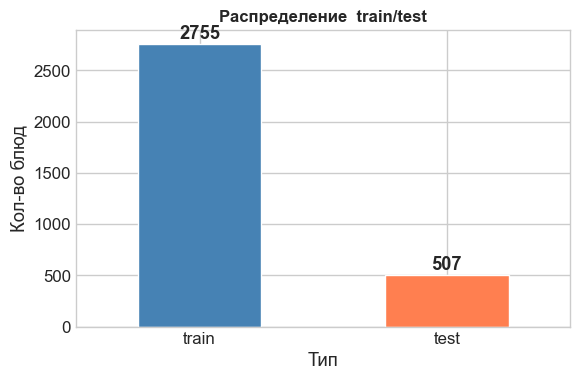

In [24]:
import matplotlib.pyplot as plt

split_counts = df_dish['split'].value_counts()
print("\nРаспределение по split:")
print(split_counts)

print(f"\nДоля обучающей выборки: "
      f"{split_counts['train'] / len(df_dish) * 100:.1f}%")
print(f"Доля тестовой выборки: "
      f"{split_counts['test'] / len(df_dish) * 100:.1f}%")

plt.figure(figsize=(6, 4))

ax = split_counts.plot(
    kind='bar',
    color=['steelblue', 'coral'],
    rot=0 
)

ax.set_title('Распределение  train/test',
             fontsize=12,
             fontweight='bold')   
ax.set_xlabel('Тип')
ax.set_ylabel('Кол-во блюд')

for i, v in enumerate(split_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Распределение по калориям


Статистика по total_calories
count    3262.000000
mean      255.012738
std       219.637570
min         0.000000
25%        80.114996
50%       209.110062
75%       375.122963
max      3943.325195
Name: total_calories, dtype: float64


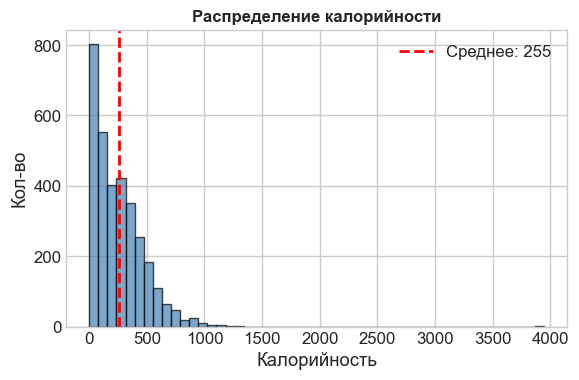

In [30]:
print(f"\nСтатистика по total_calories")
print(df_dish['total_calories'].describe())


plt.figure(figsize=(6, 4))
ax = plt.gca()                                 

ax.hist(
    df_dish['total_calories'],
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='steelblue'
)

mean_val = df_dish['total_calories'].mean()
ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее: {mean_val:.0f}'
)

ax.set_title(
    'Распределение калорийности',
    fontsize=12,
    fontweight='bold'        
)
ax.set_xlabel('Калорийность')
ax.set_ylabel('Кол-во')
ax.legend()

plt.tight_layout()
plt.show()

### Распределение по массе


Статистика по total_mass
count    3262.000000
mean      214.980074
std       161.497428
min         1.000000
25%        92.000000
50%       177.000000
75%       305.000000
max      3051.000000
Name: total_mass, dtype: float64


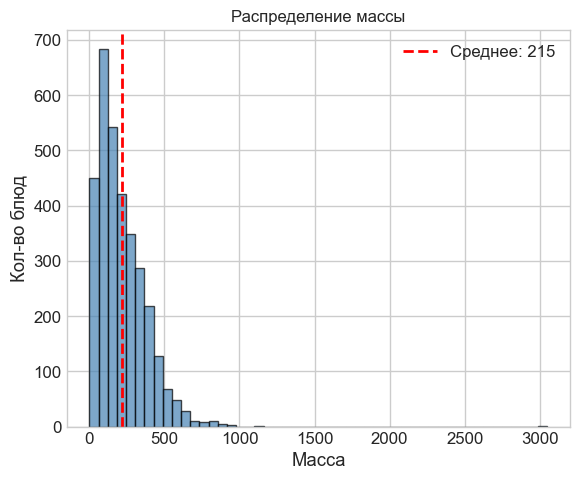

In [33]:
print(f"\nСтатистика по total_mass")
print(df_dish['total_mass'].describe())

plt.figure(figsize=(6, 5))
ax = plt.gca()                                

ax.hist(
    df_dish['total_mass'],
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='steelblue'
)

mean_val = df_dish['total_mass'].mean()
ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее: {mean_val:.0f}'
)

ax.set_title(
    'Распределение массы',
    fontsize=12,
)
ax.set_xlabel('Масса')
ax.set_ylabel('Кол-во блюд')
ax.legend()

plt.tight_layout()
plt.show()

### Распределение по ингридиентам

In [75]:
def parse_ingredient_id(ingr_str):
    if ingr_str.startswith('ingr_'):
        return str(int(ingr_str.replace('ingr_', '')))
    return ingr_str



 Статистика по количеству ингредиентов
count    3262.000000
mean        7.313305
std         6.943276
min         1.000000
25%         1.000000
50%         4.000000
75%        12.000000
max        34.000000
Name: num_ingredients, dtype: float64


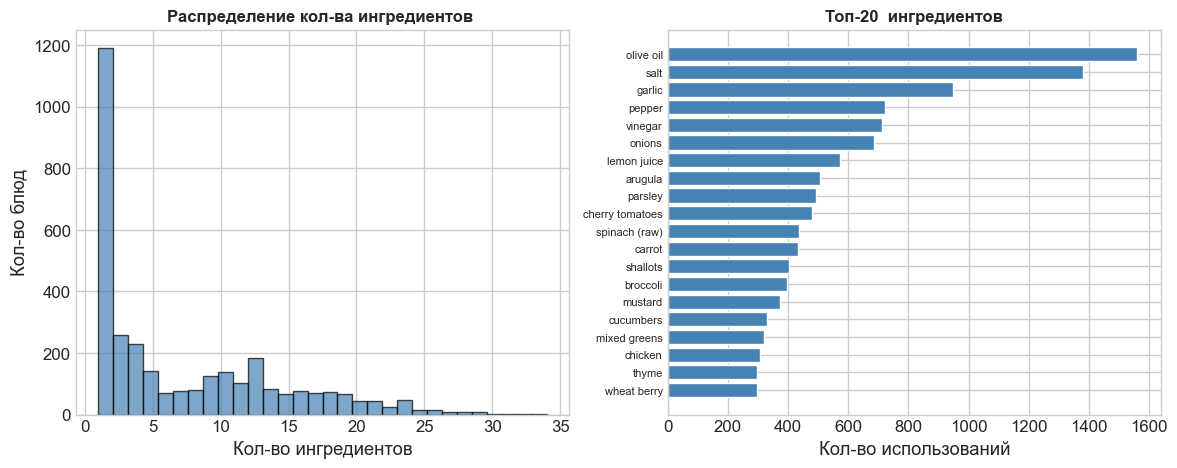

In [49]:
print(f"\n Статистика по количеству ингредиентов")


df_dish['num_ingredients'] = df_dish['ingredients'].apply(
    lambda x: len(str(x).split(';'))
)

# Подсчет частоты использования по ингредиентам
all_ingredient_ids = []
for ingredients_str in df_dish['ingredients']:
    ids = str(ingredients_str).split(';')
    all_ingredient_ids.extend(ids)

ingredient_counts = pd.Series(all_ingredient_ids).value_counts()

top_20 = ingredient_counts.head(20)

parsed_names = top_20.index.map(
    lambda raw_id: ingredients_dict.get( parse_ingredient_id(raw_id),   '????' )
)

print(df_dish['num_ingredients'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(df_dish['num_ingredients'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_title('Распределение кол-ва ингредиентов ', fontsize=12, fontweight='bold')
ax1.set_xlabel('Кол-во ингредиентов')
ax1.set_ylabel('Кол-во блюд')

ax2 = axes[1]
ax2.barh(range(len(top_20)), top_20.values, color='steelblue')
ax2.set_yticks(range(len(top_20)))
ax2.set_yticklabels(parsed_names, fontsize=8)
ax2.set_title('Топ-20  ингредиентов', fontsize=12, fontweight='bold')
ax2.set_xlabel('Кол-во использований')
ax2.invert_yaxis()

plt.show()


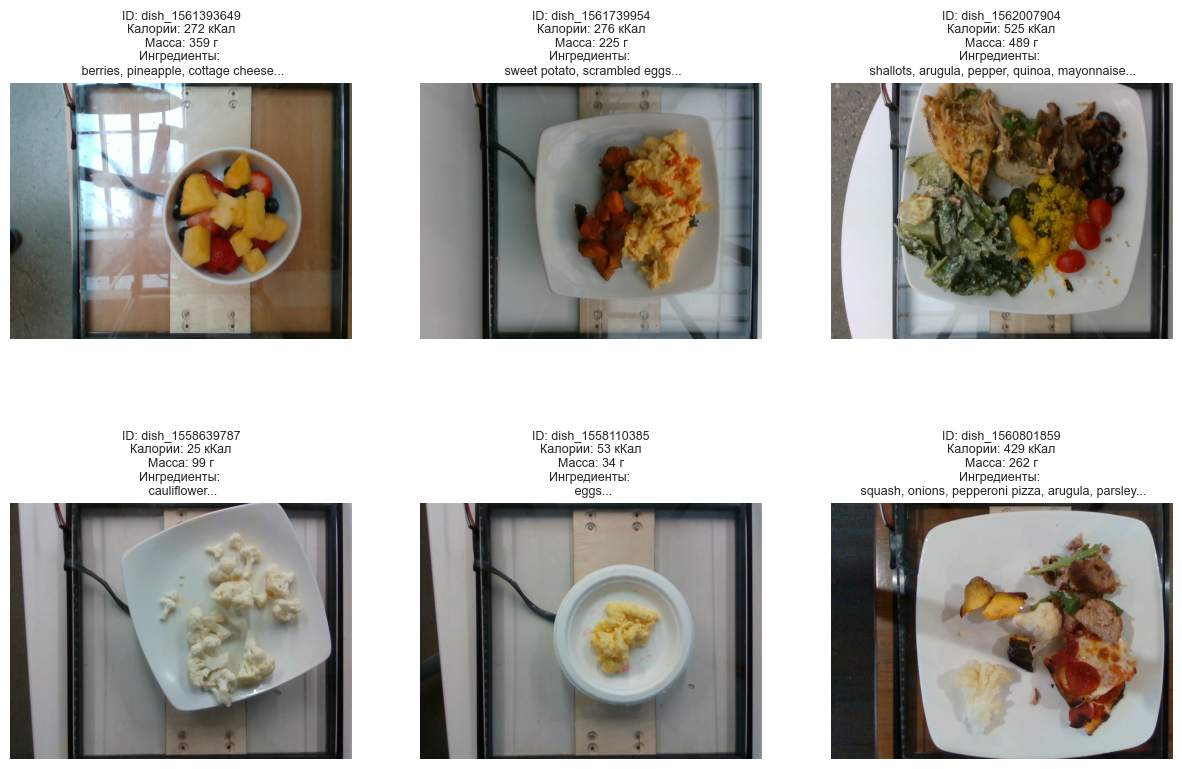

In [74]:

def visualize_dish_samples(df_dish, images_path, n_samples=6):
    sample_dishes = df_dish.sample(n=n_samples, random_state=42)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (_, dish) in enumerate(sample_dishes.iterrows()):
        dish_id = dish['dish_id']
        img_path = os.path.join(images_path, str(dish_id), 'rgb.png')
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[idx].imshow(img)
            
            # Получение названий ингредиентов
            ingr_ids = str(dish['ingredients']).split(';')
            ingr_names = []
            for ingr_id in ingr_ids[:5]:  # Первые 5 
                name = ingredients_dict.get(parse_ingredient_id(ingr_id))
                ingr_names.append(name)
            
            title = (f"ID: {dish_id}\n"
                     f"Калории: {dish['total_calories']:.0f} кКал\n"
                     f"Масса: {dish['total_mass']:.0f} г\n"
                     f"Ингредиенты: \n {', '.join(ingr_names[:5])}...")
            axes[idx].set_title(title, fontsize=9)
    
        
        axes[idx].axis('off')
    
    plt.show()

visualize_dish_samples(df_dish, IMAGES_PATH, n_samples=6)


# Этап 2. Пайплайн обучения

### Импорт библиотек и настройка окружения.

In [8]:

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import torch
from torchvision import transforms

# путь к скриптам (юпитер без этой строки не захотел работать)
sys.path.append('scripts')

print(f"CUDA доступна: {torch.cuda.is_available()}")

CUDA доступна: True


In [12]:
import sys

# чистим кэш
if 'scripts.config' in sys.modules:
    del sys.modules['scripts.config']
    del sys.modules['scripts.dataset']
    del sys.modules['scripts.utils']
    del sys.modules['scripts.model']

In [13]:

from scripts.config import CONFIG

print("Конфигурация :\n")

for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Конфигурация :

  ingredients_path: data/ingredients.csv
  dish_path: data/dish.csv
  images_dir: data/images
  text_model_name: distilbert-base-uncased
  image_model_name: tf_efficientnet_b0
  batch_size: 32
  num_epochs: 40
  learning_rate: 0.0001
  val_ratio: 0.2
  random_seed: 42
  image_size: 224
  num_workers: 0
  device: cuda
  model_save_path: models/best_model_v2.pth
  early_stopping_patience: 7


### Подготовка модели и обучение

In [14]:

from scripts.utils import train_model
from scripts.dataset import create_dataloaders_v2
from scripts.model  import CaloriesMultimodalModel
from scripts.config  import CONFIG

from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained(CONFIG['text_model_name'])
train_loader, val_loader, test_loader = create_dataloaders_v2(CONFIG, tokenizer)

model = CaloriesMultimodalModel(
        text_model_name = CONFIG['text_model_name'],
        image_model_name = CONFIG['image_model_name'],
        emb_dim=256,
        dropout=0.1
    )

results = train_model(CONFIG, train_loader, val_loader, test_loader , tokenizer, model)


print(f'Лучшая MAE на валидации: {results["best_mae"]:.2f}')

Размер выборок:
  Train: 2204
  Val: 551
  Test: 507


/home/ubuntu/scripts/dataset.py:123: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),


Устройство: cuda
Всего параметров: 71,423,871
Обучаемых: 15,946,419
Начало обучения


Эпоха 1/40


Оценка: 100%|██████████| 18/18 [00:07<00:00,  2.29it/s]


  Train MAE: 250.70
  Val MAE: 249.69
  Модель сохранена! MAE: 249.69

Эпоха 2/40


...

  Train MAE: 73.84
  Val MAE: 63.06

Эпоха 39/40


Оценка: 100%|██████████| 18/18 [00:07<00:00,  2.27it/s]


  Train MAE: 76.20
  Val MAE: 53.82
  Модель сохранена! MAE: 53.82

Эпоха 40/40


Оценка: 100%|██████████| 18/18 [00:07<00:00,  2.27it/s]

  Train MAE: 72.74
  Val MAE: 55.42
Лучшая MAE на валидации: 53.82


### Оценка модели

In [15]:
"""model = CaloriesMultimodalModel(
    text_model_name='distilbert-base-uncased',
    image_model_name='resnet50',
).to(CONFIG['device'])

model.load_state_dict(
    torch.load(CONFIG['model_save_path'], 
    map_location=CONFIG['device'])
)"""

model.eval()

predictions_list = []
true_values_list = []
dish_ids_list = []
mass_list = []
ingredient_texts_list = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Inference'):
        input_ids = batch['input_ids'].to(CONFIG['device'])
        attention_mask = batch['attention_mask'].to(CONFIG['device'])
        images = batch['image'].to(CONFIG['device'])
        mass = batch['mass'].to(CONFIG['device'])
        calories = batch['calories']
        dish_ids = batch['dish_id']
        ingredient_texts = batch['ingredient_text']
        
        predictions = model(input_ids, attention_mask, images, mass)
        
        predictions_list.extend(predictions.cpu().numpy())
        true_values_list.extend(calories.numpy())
        dish_ids_list.extend(dish_ids)
        mass_list.extend(mass.cpu().numpy())
        ingredient_texts_list.extend(ingredient_texts)

results_df = pd.DataFrame({
    'dish_id': dish_ids_list,
    'true_calories': true_values_list,
    'pred_calories': predictions_list,
    'mass': mass_list,
    'ingredient_text': ingredient_texts_list
})

#  MAE
mae = np.mean(np.abs(results_df['true_calories'] - results_df['pred_calories']))

print("Результаты на тестовой выборке: \n")
print(f"Test MAE: {mae:.2f} кКал")
print(f"Целевая метрика: MAE < 50")
#print(f"Результат: {'ДОСТИГНУТА ' if mae < 50 else 'НЕ ДОСТИГНУТА '}")


Inference: 100%|██████████| 16/16 [00:07<00:00,  2.13it/s]

Результаты на тестовой выборке: 

Test MAE: 60.93 кКал
Целевая метрика: MAE < 50


## Топ-5 блюд с наибольшей ошибкой

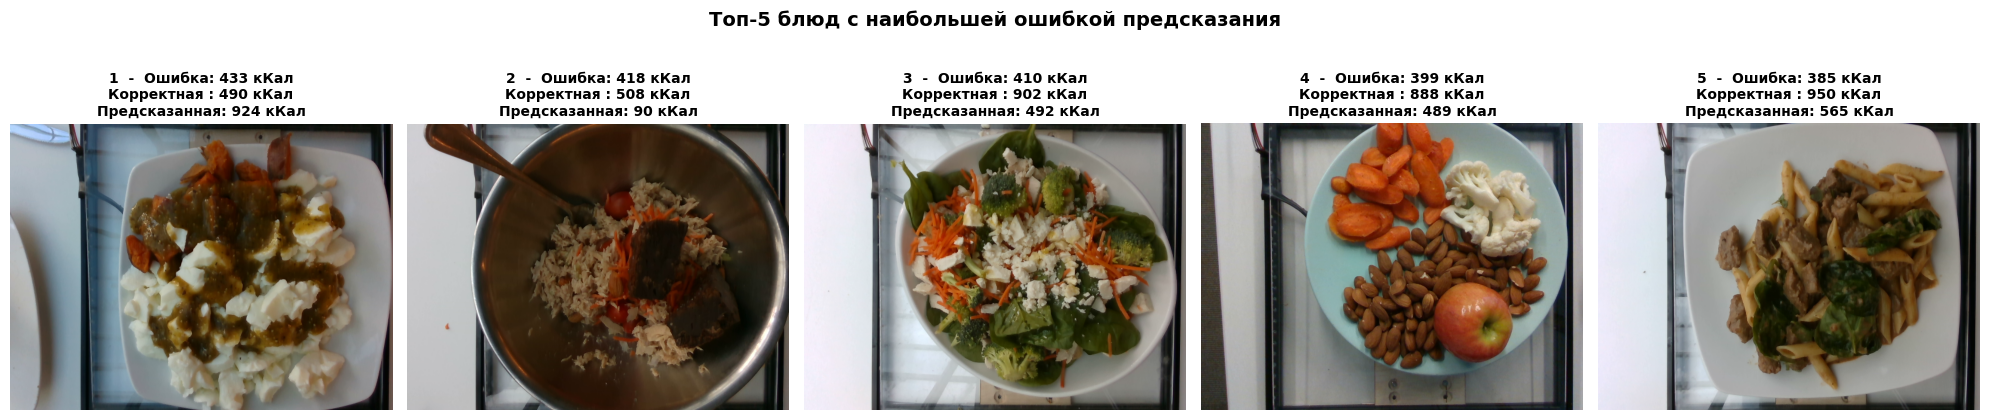

In [16]:
results_df['abs_error'] = np.abs(results_df['true_calories'] - results_df['pred_calories'])
worst_5 = results_df.nlargest(5, 'abs_error').reset_index(drop=True)


fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for idx, row in worst_5.iterrows():
    ax = axes[idx]
    
    dish_id = str(row['dish_id'])
    image_path = os.path.join(CONFIG['images_dir'], dish_id, 'rgb.png')
    
    
    img = Image.open(image_path)
    ax.imshow(img)
   
    
    ax.set_title(
        f"{idx+1}  -  Ошибка: {row['abs_error']:.0f} кКал\n"
        f"Корректная : {row['true_calories']:.0f} кКал\n"
        f"Предсказанная: {row['pred_calories']:.0f} кКал",
        fontsize=10,
        fontweight='bold',
    )
    ax.axis('off')

plt.suptitle('Топ-5 блюд с наибольшей ошибкой предсказания', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()